# Channel Flow

### Import Library

In [25]:
import numpy as np
import matplotlib.pyplot as plt

### Domain Setup

In [26]:
LH = 1.0   # Full channel height
LW = 2.0   # Streamwise domain length (periodic in x)
LZ = 1.0   # Spanwise domain length (periodic in z) -- needed for genuine 3D DNS

Dh = 2 * LH  # Hydraulic diameter for wide channel: Dh = 4A/P = 4(H*W)/(2W) = 2H
print("Hydraulic diameter (Dh):", Dh)

Re = 6000                  # Reynolds number (based on Dh and bulk velocity)
Nu = 1.5e-5                # Kinematic viscosity [m^2/s]
U_bulk = Re * Nu / Dh      # Bulk inlet velocity from Re definition
print("Bulk velocity (U_bulk):", U_bulk)

rho = 1.2                  # Air density [kg/m^3]

Hydraulic diameter (Dh): 2.0
Bulk velocity (U_bulk): 0.045


### Compute y+

In [27]:
target_y_plus = 1.0

# Blasius correlation for INTERNAL flow (channel/pipe): valid for Re < 10^5
# Darcy friction factor: f = 0.316 / Re^0.25
# Skin friction coeff:   Cf = f / 4 = 0.079 / Re^0.25
C_f = 0.079 / Re**0.25
print("Friction coefficient (Cf):", C_f)

tau_w = C_f * 0.5 * rho * U_bulk**2
print("Wall shear stress (tau_w):", tau_w)

u_tau = np.sqrt(tau_w / rho)
print("Friction velocity (u_tau):", u_tau)

# First cell height to achieve target y+
y1 = target_y_plus * Nu / u_tau
print("First cell height (y1):", y1)

# Friction Reynolds number Re_tau = u_tau * (LH/2) / Nu
H = LH / 2   # Half-channel height (use symmetry)
Re_tau = u_tau * H / Nu
print("Friction Reynolds number (Re_tau):", Re_tau)

Friction coefficient (Cf): 0.008976132995093245
Wall shear stress (tau_w): 1.0906001589038292e-05
Friction velocity (u_tau): 0.003014686494070637
First cell height (y1): 0.0049756417556194935
Friction Reynolds number (Re_tau): 100.48954980235457


### Compute the Normal Grid

Grid points: 21
First cell height: 0.004976  (target y1=0.004976)
Last point: 0.5000  (should be H=0.5)
y+ at first point: 1.000  (target: 1.0)


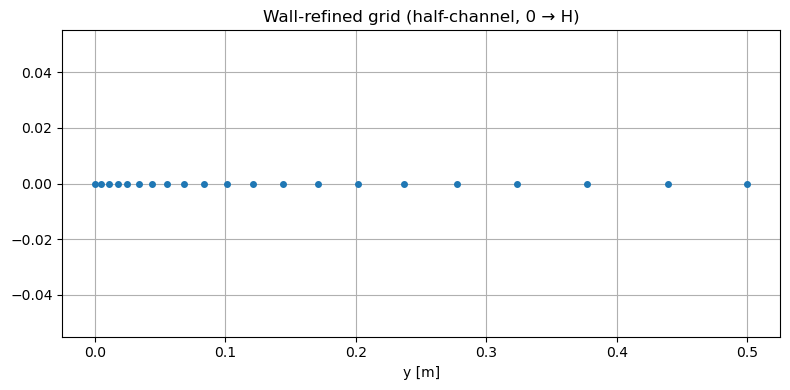

In [28]:
def exponential_grid_stretching(y1, r, H, N_max=200):
    """
    Build a wall-refined 1D grid from y=0 to y=H.
    y1   : first cell height (controls y+ at wall)
    r    : stretching ratio between successive cells
    H    : domain extent (half-channel height)
    Returns y array that always ends exactly at H.
    """
    y = [0.0]
    dy = y1
    while y[-1] + dy < H:
        y.append(y[-1] + dy)
        dy *= r
        if len(y) > N_max:
            break
    y.append(H)   # force last point exactly at centerline
    return np.array(y)


r = 1.15
y_half = exponential_grid_stretching(y1, r, H)
N = len(y_half)
print(f"Grid points: {N}")
print(f"First cell height: {y_half[1]:.6f}  (target y1={y1:.6f})")
print(f"Last point: {y_half[-1]:.4f}  (should be H={H})")
print(f"y+ at first point: {y_half[1] * u_tau / Nu:.3f}  (target: {target_y_plus})")

plt.figure(figsize=(8, 4))
plt.plot(y_half, np.zeros_like(y_half), 'o', markersize=4)
plt.xlabel("y [m]")
plt.title("Wall-refined grid (half-channel, 0 → H)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Mesh Generate

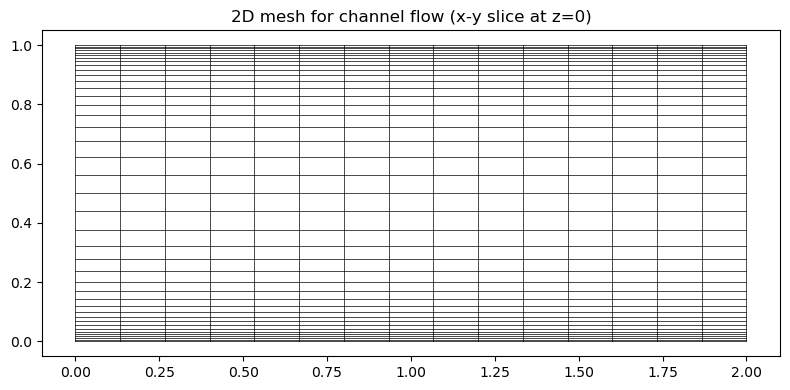

In [29]:
x = np.linspace(0, LW, 16)
z = np.linspace(0, LZ, 16)
y_lower = y_half                              # 0 → H, fine near 0 (bottom wall) ✓ already correct
y_upper = LH - y_half[::-1]                   # H → LH, fine near LH (top wall)
y = np.concatenate([y_lower, y_upper[1:]])    # drop duplicate H at the join

# 3D grid: axis 0 = y (wall-normal, non-uniform), axis 1 = z (spanwise, uniform,
# periodic), axis 2 = x (streamwise, uniform, periodic).
Yg, Zg, Xg = np.meshgrid(y, z, x, indexing='ij')
mesh = (Xg, Yg, Zg)

plt.figure(figsize=(8, 4))
plt.plot(mesh[0][:, 0, :], mesh[1][:, 0, :], 'k-', linewidth=0.5)   # x-y mesh, z=0 slice
plt.plot(mesh[0][:, 0, :].T, mesh[1][:, 0, :].T, 'k-', linewidth=0.5)
plt.title("2D mesh for channel flow (x-y slice at z=0)")
plt.tight_layout()
plt.show()

In [30]:
print("Mesh shape (Ny, Nz, Nx):", mesh[0].shape)
print("x range:", mesh[0].min(), "to", mesh[0].max())
print("y range:", mesh[1].min(), "to", mesh[1].max())
print("z range:", mesh[2].min(), "to", mesh[2].max())

Mesh shape (Ny, Nz, Nx): (41, 16, 16)
x range: 0.0 to 2.0
y range: 0.0 to 1.0
z range: 0.0 to 1.0


### stability setup

In [31]:
Nx = len(x)
Ny = len(y)
Nz = len(z)

print("Number of grid points in x-direction (Nx):", Nx)
print("Number of grid points in y-direction (Ny):", Ny)
print("Number of grid points in z-direction (Nz):", Nz)

dx = x[1] - x[0]  # Uniform grid in x-direction
dz = z[1] - z[0]  # Uniform grid in z-direction
dy_arr = np.diff(y)      # length Ny-1, dy_arr[i] = y[i+1] - y[i]
dy_s = dy_arr[:-1]        # spacing to the neighbor below, for each interior point (length Ny-2)
dy_n = dy_arr[1:]         # spacing to the neighbor above, for each interior point (length Ny-2)

print("Grid spacing in x-direction (dx):", dx)
print("Grid spacing in z-direction (dz):", dz)
print("Grid spacing in y-direction (dy_s):", dy_s)
print("Grid spacing in y-direction (dy_n):", dy_n)

safety_factor = 0.5
dx_min = np.min(dx)
dz_min = np.min(dz)
dy_min = np.min(dy_s)  # Using dy_s for consistency

dt = safety_factor / (U_bulk / dx_min + U_bulk / dz_min + U_bulk / dy_min
                       + 2 * Nu * (1/dx_min**2 + 1/dy_min**2 + 1/dz_min**2))
print("Time step (dt):", dt)

CFL_x = U_bulk * dt / dx_min
CFL_y = U_bulk * dt / dy_min
CFL_z = U_bulk * dt / dz_min

r = Nu * dt / dx_min**2

print("CFL number in x-direction:", CFL_x)
print("CFL number in y-direction:", CFL_y)
print("CFL number in z-direction:", CFL_z)
print("Diffusion number:", r)
print(f"Combined = {CFL_x + CFL_y + CFL_z + 6*r:.4f}  (must be ≤ 1)")

# Reshape to (Ny-2, 1, 1) so they broadcast correctly against the
# (Ny-2, Nz-2, Nx-2) interior arrays used in momentum_predictor / etc.
dy_s = dy_s[:, None, None]
dy_n = dy_n[:, None, None]

# This is a *small illustrative* 3D DNS, not a resolved production DNS: a real
# DNS at this Re_tau needs ~10^6-10^7 points and would take far too long in
# plain NumPy. Keep nt modest -- we're looking for early transient 3D
# structure (streaks/vortices) forming from the seeded perturbation, not a
# statistically-converged turbulent state.
nt = 4000  # Number of time steps
T = nt * dt  # Total simulation time
print(f"Total simulation time T = {T:.4f}")

Number of grid points in x-direction (Nx): 16
Number of grid points in y-direction (Ny): 41
Number of grid points in z-direction (Nz): 16
Grid spacing in x-direction (dx): 0.13333333333333333
Grid spacing in z-direction (dz): 0.06666666666666667
Grid spacing in y-direction (dy_s): [0.00497564 0.00572199 0.00658029 0.00756733 0.00870243 0.01000779
 0.01150896 0.01323531 0.0152206  0.01750369 0.02012925 0.02314863
 0.02662093 0.03061407 0.03520618 0.0404871  0.04656017 0.05354419
 0.06157582 0.06108963 0.06108963 0.06157582 0.05354419 0.04656017
 0.0404871  0.03520618 0.03061407 0.02662093 0.02314863 0.02012925
 0.01750369 0.0152206  0.01323531 0.01150896 0.01000779 0.00870243
 0.00756733 0.00658029 0.00572199]
Grid spacing in y-direction (dy_n): [0.00572199 0.00658029 0.00756733 0.00870243 0.01000779 0.01150896
 0.01323531 0.0152206  0.01750369 0.02012925 0.02314863 0.02662093
 0.03061407 0.03520618 0.0404871  0.04656017 0.05354419 0.06157582
 0.06108963 0.06108963 0.06157582 0.05354419

### Initial Condition

In [32]:
# Start from the *known* fully-developed laminar solution (not a uniform
# profile) plus a small random 3D perturbation. This isolates the question we
# actually care about -- does the perturbation grow (transition) or decay
# (relaminarize)? -- instead of confounding it with the base flow's own slow
# diffusion toward the parabola (which needs far more than nt steps to finish
# on its own, as we saw in the periodic 2D run).
rng = np.random.default_rng(0)
perturb_amp = 0.05 * U_bulk

u_analytical_3d = 6 * U_bulk * (mesh[1] / LH) * (1 - mesh[1] / LH)  # broadcasts over x, z
u = u_analytical_3d + perturb_amp * rng.standard_normal(mesh[0].shape)
v = perturb_amp * rng.standard_normal(mesh[0].shape)
w = perturb_amp * rng.standard_normal(mesh[0].shape)
p = np.zeros(mesh[0].shape)
print("Initial velocity field shape:", u.shape)

Initial velocity field shape: (41, 16, 16)


### Body Force (periodic channel forcing)

In [33]:
# Periodic channel has no inlet/outlet pressure drop to drive the flow, so we
# replace it with a constant streamwise body force (= mean pressure gradient).
# From the exact plane-Poiseuille solution: dp/dx = -12*mu*U_bulk/LH^2
# Force per unit mass added to the u-momentum equation: f_x = -(1/rho)*dp/dx = 12*Nu*U_bulk/LH^2
f_x = 12 * Nu * U_bulk / LH**2
print("Body force f_x:", f_x)

Body force f_x: 8.1e-06


## Algorithm Per Time Step

### Apply BC

In [34]:
def apply_boundary_conditions(u, v, w):
    # Periodic in x: column 0 wraps to the second-to-last column, and the last
    # column wraps to the second column (axis=2), so interior stencils at the
    # domain edges see the correct periodic neighbor. Same idea in z (axis=1).
    u[:, :, 0] = u[:, :, -2]
    v[:, :, 0] = v[:, :, -2]
    w[:, :, 0] = w[:, :, -2]
    u[:, :, -1] = u[:, :, 1]
    v[:, :, -1] = v[:, :, 1]
    w[:, :, -1] = w[:, :, 1]

    u[:, 0, :] = u[:, -2, :]
    v[:, 0, :] = v[:, -2, :]
    w[:, 0, :] = w[:, -2, :]
    u[:, -1, :] = u[:, 1, :]
    v[:, -1, :] = v[:, 1, :]
    w[:, -1, :] = w[:, 1, :]

    # Top and bottom boundary conditions (No-slip), axis=0
    u[0, :, :] = 0.0
    v[0, :, :] = 0.0
    w[0, :, :] = 0.0
    u[-1, :, :] = 0.0
    v[-1, :, :] = 0.0
    w[-1, :, :] = 0.0

    return u, v, w

## Momentum Predictor - Compute u*, v* (momentum without pressure)

In [35]:
def momentum_predictor(u, v, w, dx, dy_s, dy_n, dz, dt, Nu, f_x=0.0):
    un = u.copy()
    vn = v.copy()
    wn = w.copy()

    u_star = un.copy()
    v_star = vn.copy()
    w_star = wn.copy()

    I = (slice(1, -1), slice(1, -1), slice(1, -1))  # interior (y, z, x)

    def neighbors(A):
        c = A[1:-1, 1:-1, 1:-1]
        e = A[1:-1, 1:-1, 2:]    # x+1
        w_ = A[1:-1, 1:-1, :-2]  # x-1
        n = A[2:, 1:-1, 1:-1]    # y+1
        s = A[:-2, 1:-1, 1:-1]   # y-1
        f = A[1:-1, 2:, 1:-1]    # z+1
        b = A[1:-1, :-2, 1:-1]   # z-1
        return c, e, w_, n, s, f, b

    u_c, u_e, u_w, u_n, u_s, u_f, u_b = neighbors(un)
    v_c, v_e, v_w, v_n, v_s, v_f, v_b = neighbors(vn)
    w_c, w_e, w_w, w_n, w_s, w_f, w_b = neighbors(wn)

    # Convection terms - Upwind scheme.
    # y-direction uses one-sided spacing: dy_s (south neighbor) for the
    # backward difference, dy_n (north neighbor) for the forward difference,
    # since the grid is wall-stretched (non-uniform) in y. x and z are uniform.
    def upwind(vel_c, phi_c, phi_minus, phi_plus, d_minus, d_plus):
        return np.maximum(vel_c, 0) * (phi_c - phi_minus) / d_minus \
            + np.minimum(vel_c, 0) * (phi_plus - phi_c) / d_plus

    conv_u = upwind(u_c, u_c, u_w, u_e, dx, dx) \
        + upwind(v_c, u_c, u_s, u_n, dy_s, dy_n) \
        + upwind(w_c, u_c, u_b, u_f, dz, dz)

    conv_v = upwind(u_c, v_c, v_w, v_e, dx, dx) \
        + upwind(v_c, v_c, v_s, v_n, dy_s, dy_n) \
        + upwind(w_c, v_c, v_b, v_f, dz, dz)

    conv_w = upwind(u_c, w_c, w_w, w_e, dx, dx) \
        + upwind(v_c, w_c, w_s, w_n, dy_s, dy_n) \
        + upwind(w_c, w_c, w_b, w_f, dz, dz)

    # Diffusion terms. x, z uniform -> standard central difference.
    # y non-uniform -> weighted (dy_s, dy_n) second-derivative stencil:
    #   d2u/dy2 ~= 2*(u_n*dy_s + u_s*dy_n - u*(dy_s+dy_n)) / (dy_s*dy_n*(dy_s+dy_n))
    def diffusion(c, e, w_, n, s, f, b):
        d_x = (e - 2 * c + w_) / dx**2
        d_y = 2 * (n * dy_s + s * dy_n - c * (dy_s + dy_n)) / (dy_s * dy_n * (dy_s + dy_n))
        d_z = (f - 2 * c + b) / dz**2
        return Nu * (d_x + d_y + d_z)

    diff_u = diffusion(u_c, u_e, u_w, u_n, u_s, u_f, u_b)
    diff_v = diffusion(v_c, v_e, v_w, v_n, v_s, v_f, v_b)
    diff_w = diffusion(w_c, w_e, w_w, w_n, w_s, w_f, w_b)

    # f_x: constant streamwise body force replacing the mean pressure gradient
    # that a periodic domain can't sustain on its own.
    u_star[I] = u_c + dt * (diff_u - conv_u + f_x)
    v_star[I] = v_c + dt * (diff_v - conv_v)
    w_star[I] = w_c + dt * (diff_w - conv_w)

    return u_star, v_star, w_star

## Compute divergence b = ∇·u*

In [36]:
# compute the divergence of the intermediate velocity field
def compute_divergence(u_star, v_star, w_star, dx, dy_s, dy_n, dz):
    du_dx = (u_star[1:-1, 1:-1, 2:] - u_star[1:-1, 1:-1, :-2]) / (2 * dx)

    # Non-uniform central difference for dv/dy:
    #   f'_i ~= [dy_s^2*(f_n - f_i) + dy_n^2*(f_i - f_s)] / (dy_s*dy_n*(dy_s+dy_n))
    # (reduces to the standard (f_n - f_s)/(2*dy) when dy_s == dy_n)
    v_c = v_star[1:-1, 1:-1, 1:-1]
    v_n = v_star[2:, 1:-1, 1:-1]
    v_s = v_star[:-2, 1:-1, 1:-1]
    dv_dy = (dy_s**2 * (v_n - v_c) + dy_n**2 * (v_c - v_s)) / (dy_s * dy_n * (dy_s + dy_n))

    dw_dz = (w_star[1:-1, 2:, 1:-1] - w_star[1:-1, :-2, 1:-1]) / (2 * dz)

    div = du_dx + dv_dy + dw_dz
    return div

## Connector - Pressure Poisson Solver

In [37]:
def pressure_poisson_connector(u_star, v_star, w_star, p, dx, dy_s, dy_n, dz, dt, rho=1.0, max_iter=400, tol=1e-4):
    # Non-uniform 5-point (y) + uniform (x, z) Laplacian weights.
    # d2p/dy2 ~= Ay_n*p_n + Ay_s*p_s - Ay_center*p   (Ay_center = Ay_n + Ay_s)
    Ax = 1.0 / dx**2
    Az = 1.0 / dz**2
    Ay_n = 2.0 / (dy_n * (dy_s + dy_n))
    Ay_s = 2.0 / (dy_s * (dy_s + dy_n))
    Ay_center = Ay_n + Ay_s

    for it in range(max_iter):
        p_old = p.copy()

        # Neighbours of p - interior points only
        p_e = p_old[1:-1, 1:-1, 2:]   # x+1
        p_w = p_old[1:-1, 1:-1, :-2]  # x-1
        p_n = p_old[2:, 1:-1, 1:-1]   # y+1
        p_s = p_old[:-2, 1:-1, 1:-1]  # y-1
        p_f = p_old[1:-1, 2:, 1:-1]   # z+1
        p_b = p_old[1:-1, :-2, 1:-1]  # z-1

        div = compute_divergence(u_star, v_star, w_star, dx, dy_s, dy_n, dz)

        rhs = (rho / dt) * div

        # Jacobi update for pressure
        p[1:-1, 1:-1, 1:-1] = (Ax * (p_e + p_w) + Az * (p_f + p_b)
                                + Ay_n * p_n + Ay_s * p_s - rhs) / (2 * Ax + 2 * Az + Ay_center)

        # Boundary conditions for pressure: Neumann (dp/dn=0) at the walls,
        # periodic in x and z (matching the velocity BCs).
        p[0, :, :] = p[1, :, :]     # dp/dy=0 at bottom
        p[-1, :, :] = p[-2, :, :]   # dp/dy=0 at top
        p[:, :, 0] = p[:, :, -2]
        p[:, :, -1] = p[:, :, 1]
        p[:, 0, :] = p[:, -2, :]
        p[:, -1, :] = p[:, 1, :]

        # Periodic-x/z + all-Neumann-y BCs leave the pressure defined only up
        # to an additive constant (no Dirichlet reference anywhere) -> pin it
        # by removing the mean every iteration.
        p -= p.mean()

        if np.linalg.norm(p - p_old) < tol:
            break
    else:
        print("Pressure Poisson did not converge within the maximum iterations.")

    return p

## Correct: u = u* - dt·∂p/∂x,  v = v* - dt·∂p/∂y

In [38]:
def velocity_corrector(u_star, v_star, w_star, p, dx, dy_s, dy_n, dz, dt, rho=1.0):
    u = u_star.copy()
    v = v_star.copy()
    w = w_star.copy()

    p_e = p[1:-1, 1:-1, 2:]   # x+1
    p_w = p[1:-1, 1:-1, :-2]  # x-1
    p_c = p[1:-1, 1:-1, 1:-1]
    p_n = p[2:, 1:-1, 1:-1]   # y+1
    p_s = p[:-2, 1:-1, 1:-1]  # y-1
    p_f = p[1:-1, 2:, 1:-1]   # z+1
    p_b = p[1:-1, :-2, 1:-1]  # z-1

    # Non-uniform central difference for dp/dy (same weighting as compute_divergence)
    dp_dy = (dy_s**2 * (p_n - p_c) + dy_n**2 * (p_c - p_s)) / (dy_s * dy_n * (dy_s + dy_n))

    u[1:-1, 1:-1, 1:-1] = u_star[1:-1, 1:-1, 1:-1] - (dt / rho) * (p_e - p_w) / (2 * dx)
    v[1:-1, 1:-1, 1:-1] = v_star[1:-1, 1:-1, 1:-1] - (dt / rho) * dp_dy
    w[1:-1, 1:-1, 1:-1] = w_star[1:-1, 1:-1, 1:-1] - (dt / rho) * (p_f - p_b) / (2 * dz)

    return u, v, w

## Track ${max|u^{n+1} - u^n|}$ for steady state convergence

In [39]:
def check_convergence(u, v, w, u_old, v_old, w_old, tol=1e-4):
    du = np.linalg.norm(u - u_old)
    dv = np.linalg.norm(v - v_old)
    dw = np.linalg.norm(w - w_old)
    return du < tol and dv < tol and dw < tol

## main loop

In [40]:
residual_history = []
u_history = []
v_history = []
w_history = []
p_history = []

for n in range(nt):
    u_old = u.copy()
    v_old = v.copy()
    w_old = w.copy()
    p_old = p.copy()

    u_old, v_old, w_old = apply_boundary_conditions(u_old, v_old, w_old)
    u_star, v_star, w_star = momentum_predictor(u_old, v_old, w_old, dx, dy_s, dy_n, dz, dt, Nu, f_x=f_x)
    p = pressure_poisson_connector(u_star, v_star, w_star, p_old, dx, dy_s, dy_n, dz, dt, rho=rho)
    u, v, w = velocity_corrector(u_star, v_star, w_star, p, dx, dy_s, dy_n, dz, dt, rho=rho)

    u, v, w = apply_boundary_conditions(u, v, w)

    if n % 50 == 0:
        u_history.append(u.copy())
        v_history.append(v.copy())
        w_history.append(w.copy())
        p_history.append(p.copy())

    residual = np.max(np.abs(u - u_old))
    residual_history.append(residual)
    if n % 100 == 0:
        print(f"Step {n:4d} | residual = {residual:.2e}")

    if check_convergence(u, v, w, u_old, v_old, w_old, tol=1e-8):
        print(f"Converged to steady state at step {n}")
        break

Pressure Poisson did not converge within the maximum iterations.
Step    0 | residual = 1.22e-03
Step  100 | residual = 3.12e-05
Step  200 | residual = 1.76e-05
Step  300 | residual = 1.28e-05
Step  400 | residual = 1.47e-05
Step  500 | residual = 9.28e-06
Step  600 | residual = 1.15e-05
Step  700 | residual = 7.94e-06
Step  800 | residual = 7.78e-06
Step  900 | residual = 7.03e-06
Step 1000 | residual = 6.31e-06
Step 1100 | residual = 5.47e-06
Step 1200 | residual = 5.31e-06
Step 1300 | residual = 4.43e-06
Step 1400 | residual = 4.65e-06
Step 1500 | residual = 3.66e-06
Step 1600 | residual = 3.72e-06
Step 1700 | residual = 3.44e-06
Step 1800 | residual = 2.88e-06
Step 1900 | residual = 3.11e-06
Step 2000 | residual = 2.43e-06
Step 2100 | residual = 2.46e-06
Step 2200 | residual = 2.03e-06
Step 2300 | residual = 1.85e-06
Step 2400 | residual = 1.63e-06
Step 2500 | residual = 1.42e-06
Step 2600 | residual = 1.34e-06
Step 2700 | residual = 1.06e-06
Step 2800 | residual = 1.00e-06
Step 29

### Post-processing / Visualization

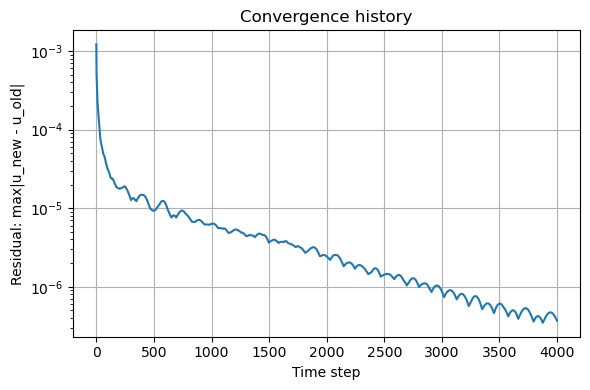

In [41]:
plt.figure(figsize=(6, 4))
plt.semilogy(residual_history)
plt.xlabel("Time step")
plt.ylabel("Residual: max|u_new - u_old|")
plt.title("Convergence history")
plt.grid(True)
plt.tight_layout()
plt.show()

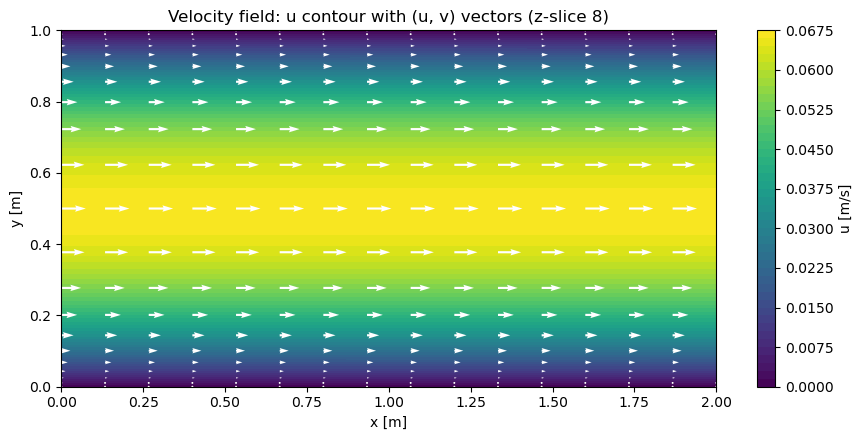

In [42]:
kz = Nz // 2  # mid-span slice for the x-y view

skip_x = max(1, Nx // 20)
skip_y = max(1, Ny // 20)

plt.figure(figsize=(9, 4.5))
cf = plt.contourf(mesh[0][:, kz, :], mesh[1][:, kz, :], u[:, kz, :], levels=50, cmap='viridis')
plt.colorbar(cf, label="u [m/s]")
plt.quiver(mesh[0][::skip_y, kz, ::skip_x], mesh[1][::skip_y, kz, ::skip_x],
           u[::skip_y, kz, ::skip_x], v[::skip_y, kz, ::skip_x],
           color='white', scale=U_bulk*40)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title(f"Velocity field: u contour with (u, v) vectors (z-slice {kz})")
plt.tight_layout()
plt.show()

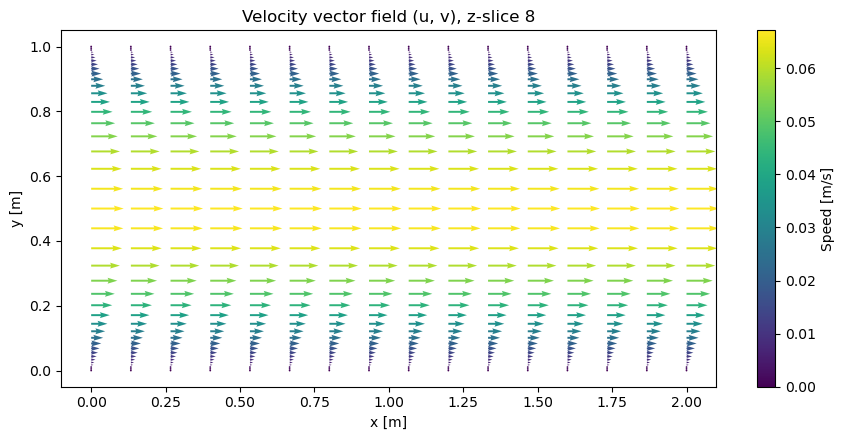

In [43]:
skip_x = max(1, Nx // 25)
skip_y = max(1, Ny // 25)
speed = np.sqrt(u[:, kz, :]**2 + v[:, kz, :]**2)

plt.figure(figsize=(9, 4.5))
q = plt.quiver(mesh[0][::skip_y, kz, ::skip_x], mesh[1][::skip_y, kz, ::skip_x],
               u[::skip_y, kz, ::skip_x], v[::skip_y, kz, ::skip_x],
               speed[::skip_y, ::skip_x], cmap='viridis',
               scale=U_bulk * 30, width=0.003)
plt.colorbar(q, label="Speed [m/s]")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title(f"Velocity vector field (u, v), z-slice {kz}")
plt.tight_layout()
plt.show()

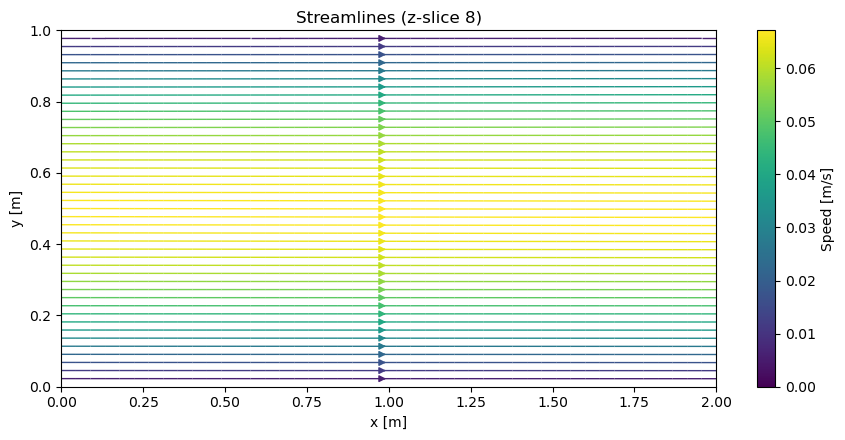

In [44]:
# streamplot requires an evenly spaced grid; interpolate u, v from the
# wall-stretched y onto a uniform y just for this plot (solver data untouched).
y_uniform = np.linspace(0, LH, Ny)
u_uniform = np.array([np.interp(y_uniform, y, u[:, kz, j]) for j in range(Nx)]).T
v_uniform = np.array([np.interp(y_uniform, y, v[:, kz, j]) for j in range(Nx)]).T
speed_uniform = np.sqrt(u_uniform**2 + v_uniform**2)

plt.figure(figsize=(9, 4.5))
strm = plt.streamplot(x, y_uniform, u_uniform, v_uniform, density=1.5, color=speed_uniform, cmap='viridis', linewidth=1)
plt.colorbar(strm.lines, label="Speed [m/s]")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title(f"Streamlines (z-slice {kz})")
plt.tight_layout()
plt.show()

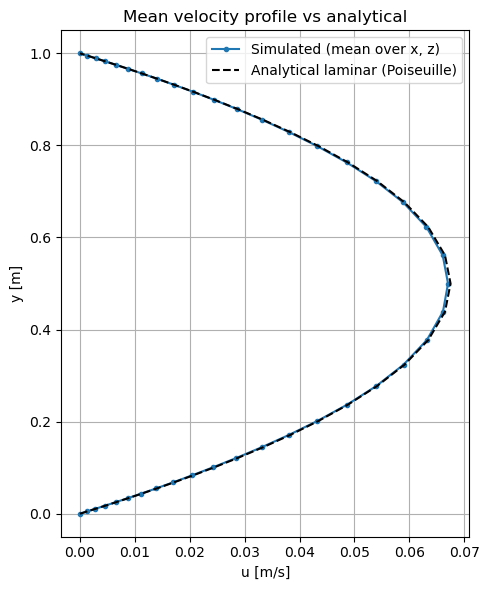

In [45]:
# Analytical fully-developed laminar (plane Poiseuille) profile for comparison:
# u(y) = 6 * U_bulk * (y/LH) * (1 - y/LH), peak = 1.5*U_bulk at centerline
u_analytical = 6 * U_bulk * (y / LH) * (1 - y / LH)

# Compare the analytical laminar solution against the mean profile averaged
# over x and z -- the right comparison for a 3D field, since any turbulent
# mixing would show up as a flatter, more plug-like mean profile.
u_mean_profile = u.mean(axis=(1, 2))

plt.figure(figsize=(5, 6))
plt.plot(u_mean_profile, y, 'o-', markersize=3, label="Simulated (mean over x, z)")
plt.plot(u_analytical, y, 'k--', label="Analytical laminar (Poiseuille)")
plt.xlabel("u [m/s]")
plt.ylabel("y [m]")
plt.title("Mean velocity profile vs analytical")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

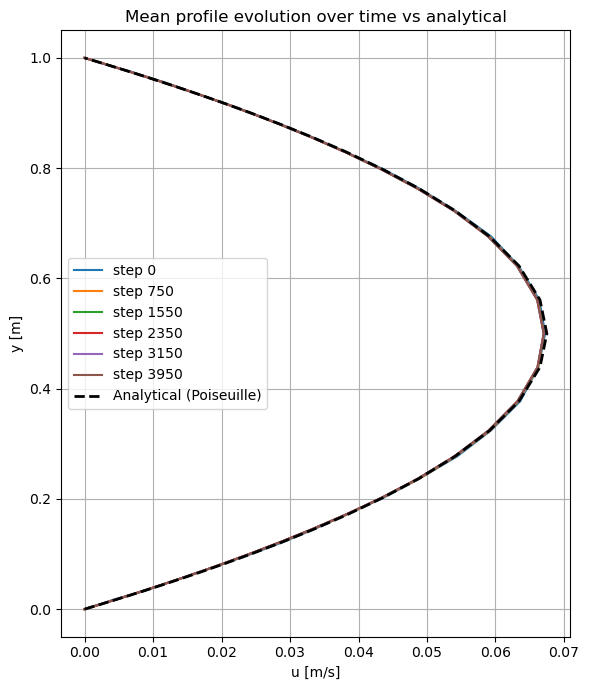

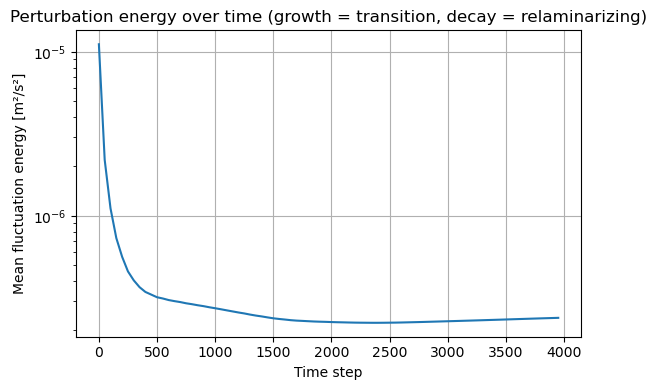

In [46]:
# Check how the mean (x,z-averaged) profile evolves over time relative to
# the analytical parabola -- and, separately, whether the perturbation is
# growing (transition) or decaying (relaminarizing).
plt.figure(figsize=(6, 7))
snapshot_indices = np.linspace(0, len(u_history) - 1, 6, dtype=int)
for idx in snapshot_indices:
    step_n = idx * 50
    mean_profile = u_history[idx].mean(axis=(1, 2))
    plt.plot(mean_profile, y, label=f"step {step_n}")
plt.plot(u_analytical, y, 'k--', linewidth=2, label="Analytical (Poiseuille)")
plt.xlabel("u [m/s]")
plt.ylabel("y [m]")
plt.title("Mean profile evolution over time vs analytical")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Perturbation energy (fluctuation kinetic energy relative to the x,z-mean)
# over time: growing -> transition/turbulence, decaying -> relaminarizing.
tke_history = []
for idx in range(len(u_history)):
    u_mean = u_history[idx].mean(axis=(1, 2), keepdims=True)
    v_mean = v_history[idx].mean(axis=(1, 2), keepdims=True)
    w_mean = w_history[idx].mean(axis=(1, 2), keepdims=True)
    fluct_energy = ((u_history[idx] - u_mean)**2
                    + (v_history[idx] - v_mean)**2
                    + (w_history[idx] - w_mean)**2).mean()
    tke_history.append(fluct_energy)

plt.figure(figsize=(6, 4))
plt.semilogy(np.arange(len(tke_history)) * 50, tke_history)
plt.xlabel("Time step")
plt.ylabel("Mean fluctuation energy [m²/s²]")
plt.title("Perturbation energy over time (growth = transition, decay = relaminarizing)")
plt.grid(True)
plt.tight_layout()
plt.show()

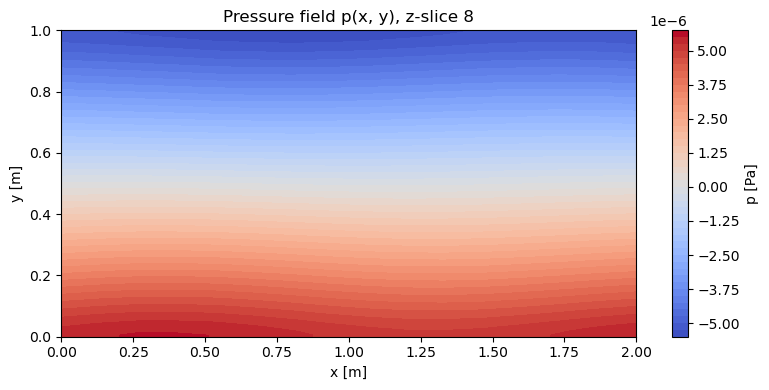

In [47]:
plt.figure(figsize=(8, 4))
cf = plt.contourf(mesh[0][:, kz, :], mesh[1][:, kz, :], p[:, kz, :], levels=50, cmap='coolwarm')
plt.colorbar(cf, label="p [Pa]")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title(f"Pressure field p(x, y), z-slice {kz}")
plt.tight_layout()
plt.show()

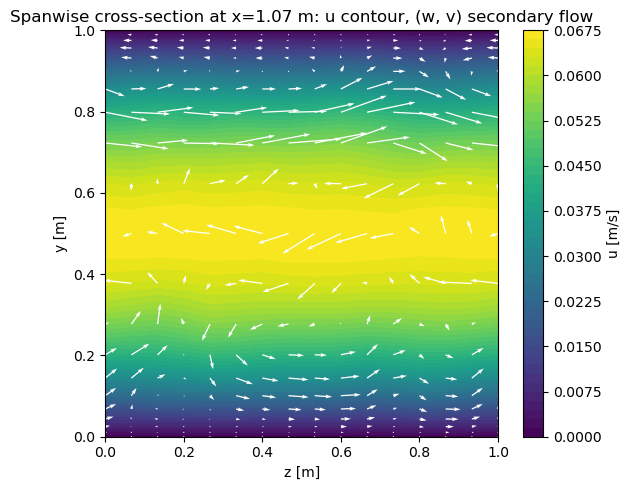

In [48]:
# Spanwise (y-z) cross-section at a fixed x: the (w, v) "secondary flow" here
# is exactly what a 2D solver can never show. Streamwise vortices/streaks, if
# present, appear as circulating patterns in this cross-section.
kx = Nx // 2

skip_y2 = max(1, Ny // 20)
skip_z2 = max(1, Nz // 20)

plt.figure(figsize=(6, 5))
cf = plt.contourf(mesh[2][:, :, kx], mesh[1][:, :, kx], u[:, :, kx], levels=50, cmap='viridis')
plt.colorbar(cf, label="u [m/s]")
plt.quiver(mesh[2][::skip_y2, ::skip_z2, kx], mesh[1][::skip_y2, ::skip_z2, kx],
           w[::skip_y2, ::skip_z2, kx], v[::skip_y2, ::skip_z2, kx],
           color='white')
plt.xlabel("z [m]")
plt.ylabel("y [m]")
plt.title(f"Spanwise cross-section at x={x[kx]:.2f} m: u contour, (w, v) secondary flow")
plt.tight_layout()
plt.show()